In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os
import numpy as np
from tensorflow.keras.preprocessing import image
import zipfile

In [11]:
tf.random.set_seed(42)
print('Tensorflow version',tf.__version__)

Tensorflow version 2.19.0


In [12]:
# Download DataSet From Kaggle.com
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d omkargurav/face-mask-dataset
!unzip face-mask-dataset.zip


Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  face-mask-dataset.zip
replace data/with_mask/with_mask_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [13]:
base_dir='data'
print('DataSet Folders:',os.listdir(base_dir))

DataSet Folders: ['with_mask', 'without_mask']


In [14]:
datagen=ImageDataGenerator(rescale=1./255,validation_split=0.2)

train_data=datagen.flow_from_directory(base_dir,
                                       target_size=(224,224),
                                       batch_size=32,
                                       class_mode='binary',
                                       subset='training',
                                       seed=42)

Found 6043 images belonging to 2 classes.


In [15]:
test_data=datagen.flow_from_directory(base_dir,
                                      target_size=(224,224),
                                      batch_size=32,
                                      class_mode='binary',
                                      subset='validation',
                                      seed=42)

Found 1510 images belonging to 2 classes.


In [24]:
# Create the CCN Model
model=tf.keras.Sequential([
    tf.keras.layers.Conv2D(16,3,activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(16,3,activation='relu'),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [26]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 220, 220, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 110, 110, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 108, 108, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 106, 106, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 53, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 51, 51, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │     2,560,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,281 (9.90 MB)

 Trainable params: 2,595,281 (9.90 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history=model.fit(train_data,epochs=5,validation_data=test_data)

Epoch 1/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.8949 - loss: 0.2662 - val_accuracy: 0.9238 - val_loss: 0.2101
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - accuracy: 0.9129 - loss: 0.2242 - val_accuracy: 0.9225 - val_loss: 0.1992
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - accuracy: 0.9254 - loss: 0.1866 - val_accuracy: 0.9291 - val_loss: 0.2056
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.9393 - loss: 0.1623 - val_accuracy: 0.9318 - val_loss: 0.1957
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - accuracy: 0.9490 - loss: 0.1214 - val_accuracy: 0.9457 - val_loss: 0.1578


In [29]:
# Evaluate
loss,accuracy=model.evaluate(test_data)

print(f'Loss:, {loss}')
print(f'Accuracy:, {accuracy}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9525 - loss: 0.1492
Loss:, 0.15776503086090088
Accuracy:, 0.9456953406333923


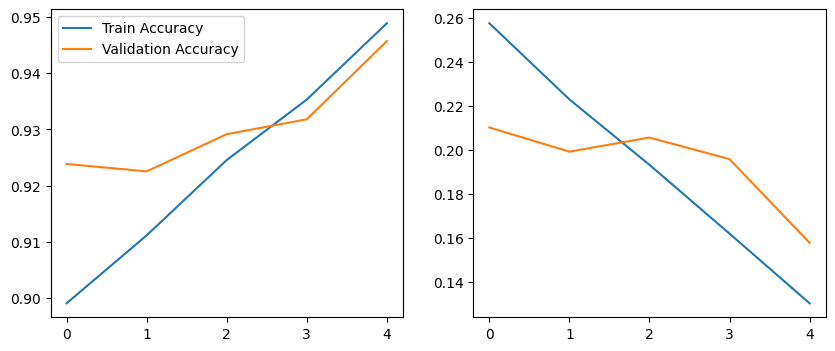

In [32]:
# plot Accuracy and Loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


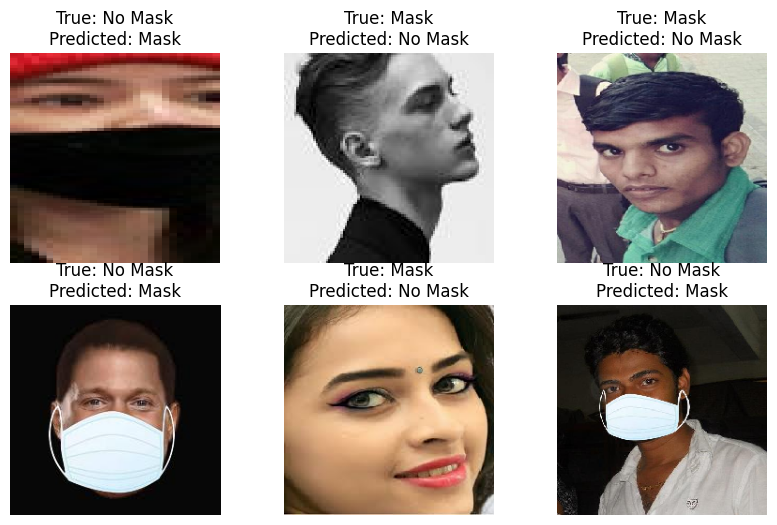

In [48]:
images,labels=next(test_data)
predictions=model.predict(images)
plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    true_label= 'No Mask' if labels[i] ==0 else 'Mask'
    predicted_label= 'No Mask'if predictions[i]>0.5 else 'Mask'
    plt.title(f'True: {true_label}\nPredicted: {predicted_label}')
    plt.axis('off')
    plt.tight_layout

Saving download.jpg to download (5).jpg
File Uploaded:  download (5).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Prediction: Mask
Confidence: 72.98267 %


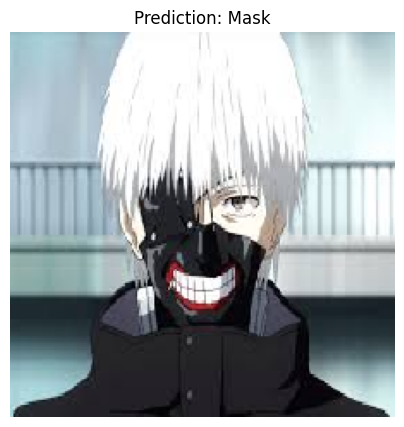

In [56]:
from google.colab import files
uploaded=files.upload()
for fn in uploaded.keys():
    img_path=fn
    print('File Uploaded: ',img_path)
    img=image.load_img(img_path,target_size=(224,224))
    img_array=image.img_to_array(img)
    img_array=np.expand_dims(img_array,axis=0)/255.0

    pred=model.predict(img_array)[0][0]
    labels='Mask' if pred<0.5 else 'No Mask'
    print('Prediction:',labels)
    print('Confidence:',100*(1-pred) if pred<0.5 else 100*pred,'%')

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(f'Prediction: {labels}')
    plt.axis('off')
    plt.show()